In [7]:
!pip install numpy matplotlib scikit-fuzzy


Nota do serviço (0-10) [7]: 7
Nota da comida (0-10) [3]: 3

=> Gorjeta sugerida: 12.5%


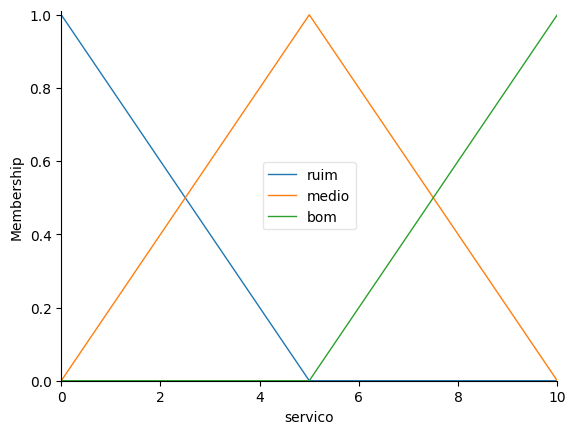

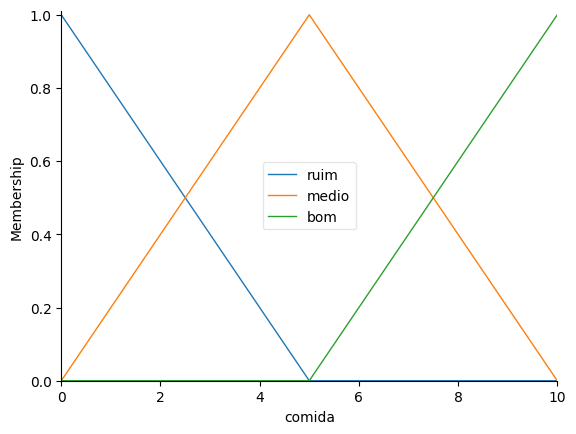

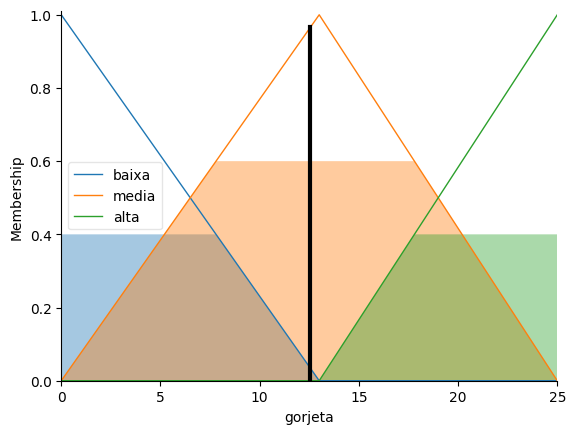

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ---------- 1) Variáveis linguísticas (universos de discurso) ----------
servico = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "servico")   # nota 0-10
comida = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "comida")     # nota 0-10
gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta")   # % da conta

# ---------- 2) Conjuntos fuzzy (funções de pertinência) ----------
for var in (servico, comida):
    var["ruim"] = fuzz.trimf(var.universe, [0, 0, 5])
    var["medio"] = fuzz.trimf(var.universe, [0, 5, 10])
    var["bom"] = fuzz.trimf(var.universe, [5, 10, 10])

gorjeta["baixa"] = fuzz.trimf(gorjeta.universe, [0, 0, 13])
gorjeta["media"] = fuzz.trimf(gorjeta.universe, [0, 13, 25])
gorjeta["alta"] = fuzz.trimf(gorjeta.universe, [13, 25, 25])

# ---------- 3) Base de regras  (| = OU, & = E, ~ = NÃO) ----------
regras = [
    ctrl.Rule(servico["ruim"] | comida["ruim"], gorjeta["baixa"]),
    ctrl.Rule(servico["medio"] & comida["medio"], gorjeta["media"]),
    ctrl.Rule(servico["bom"] | comida["bom"], gorjeta["alta"]),
]

# ---------- 4) Simulação ----------
sistema = ctrl.ControlSystem(regras)
sim = ctrl.ControlSystemSimulation(sistema)


def pedir_nota(texto, padrao):
    """Lê uma nota de 0 a 10; se o aluno só apertar Enter, usa o padrão."""
    resposta = input(f"{texto} (0-10) [{padrao}]: ").strip()
    return float(resposta.replace(",", ".")) if resposta else padrao


sim.input["servico"] = pedir_nota("Nota do serviço", 7)
sim.input["comida"] = pedir_nota("Nota da comida", 3)
sim.compute()
print(f"\n=> Gorjeta sugerida: {sim.output['gorjeta']:.1f}%")

# ---------- 5) Gráficos ----------
servico.view()                 # funções de pertinência do serviço
comida.view()                  # funções de pertinência da comida
gorjeta.view(sim=sim)          # área agregada + linha do centroide (resultado)
plt.show()

# ======================= EXPERIMENTOS =======================
# 1) Troque a regra 2 por:  servico["medio"] & comida["medio"]
#    O que mudou no resultado para (7, 3)? Por quê?
# 2) Troque os triângulos de "servico" por trapézios (fuzz.trapmf) ou
#    gaussianas (fuzz.gaussmf, [media, desvio]). O resultado ficou mais suave?
# 3) Compare métodos de defuzzificação:
#      gorjeta = ctrl.Consequent(np.arange(0, 25.01, 0.5), "gorjeta",
#                                defuzzify_method="mom")   # "centroid", "bisector", "mom"...
# 4) Adicione um 4º conjunto "excelente" ao serviço e escreva a regra nova.
# 5) Teste (0, 0), (10, 10), (5, 5): o comportamento é o que você esperava?


Nota do serviço (0-10) [7]: 7
Nota da comida (0-10) [3]: 3

EXPERIMENTO 2 - FUNÇÕES TRAPEZOIDAIS
Nota do serviço: 7.0
Nota da comida:  3.0
Gorjeta sugerida: 12.5%


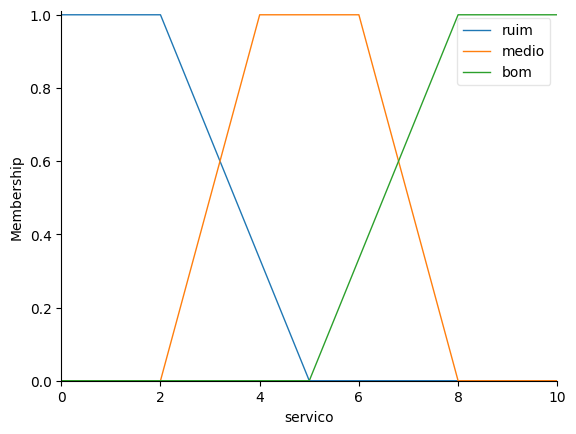

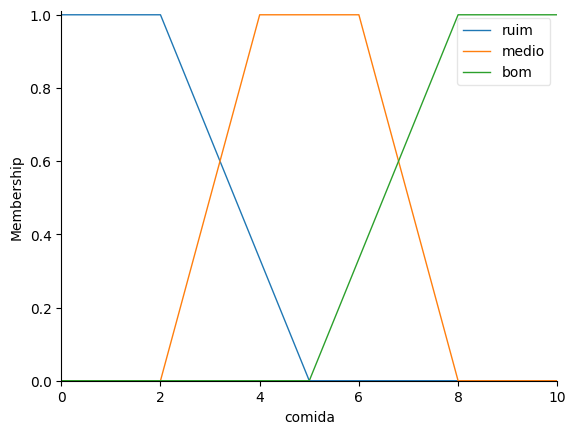

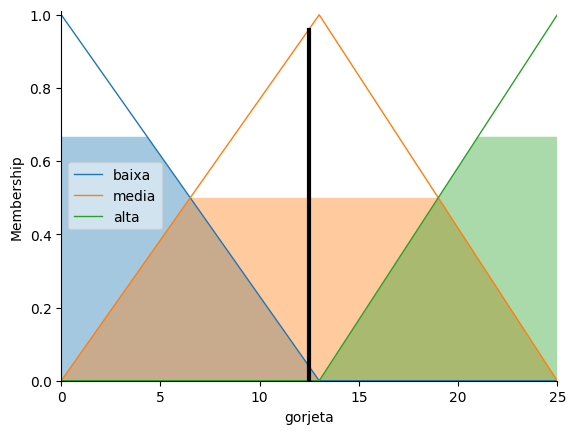

In [5]:
# ============================================================
# AULA DE LÓGICA FUZZY - Código 2
# EXPERIMENTO 2 - FUNÇÕES TRAPEZOIDAIS
# Google Colab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================================
# 1) VARIÁVEIS LINGUÍSTICAS
# ============================================================

servico = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "servico"
)

comida = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "comida"
)

gorjeta = ctrl.Consequent(
    np.arange(0, 25.01, 0.5),
    "gorjeta"
)

# ============================================================
# 2) CONJUNTOS FUZZY
# EXPERIMENTO 2: USANDO TRAPÉZIOS
# ============================================================

for var in (servico, comida):

    var["ruim"] = fuzz.trapmf(
        var.universe,
        [0, 0, 2, 5]
    )

    var["medio"] = fuzz.trapmf(
        var.universe,
        [2, 4, 6, 8]
    )

    var["bom"] = fuzz.trapmf(
        var.universe,
        [5, 8, 10, 10]
    )

# Conjuntos fuzzy da gorjeta

gorjeta["baixa"] = fuzz.trimf(
    gorjeta.universe,
    [0, 0, 13]
)

gorjeta["media"] = fuzz.trimf(
    gorjeta.universe,
    [0, 13, 25]
)

gorjeta["alta"] = fuzz.trimf(
    gorjeta.universe,
    [13, 25, 25]
)

# ============================================================
# 3) BASE DE REGRAS
# ============================================================

regras = [

    # Se serviço é ruim OU comida é ruim,
    # então a gorjeta é baixa.
    ctrl.Rule(
        servico["ruim"] | comida["ruim"],
        gorjeta["baixa"]
    ),

    # Se serviço é médio,
    # então a gorjeta é média.
    ctrl.Rule(
        servico["medio"],
        gorjeta["media"]
    ),

    # Se serviço é bom OU comida é boa,
    # então a gorjeta é alta.
    ctrl.Rule(
        servico["bom"] | comida["bom"],
        gorjeta["alta"]
    )
]

# ============================================================
# 4) CRIAR O SISTEMA FUZZY
# ============================================================

sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

# ============================================================
# 5) ENTRADA DAS NOTAS
# ============================================================

def pedir_nota(texto, padrao):

    resposta = input(
        f"{texto} (0-10) [{padrao}]: "
    ).strip()

    if resposta == "":
        return padrao

    return float(
        resposta.replace(",", ".")
    )


nota_servico = pedir_nota(
    "Nota do serviço",
    7
)

nota_comida = pedir_nota(
    "Nota da comida",
    3
)

# ============================================================
# 6) EXECUTAR A SIMULAÇÃO
# ============================================================

sim.input["servico"] = nota_servico
sim.input["comida"] = nota_comida

sim.compute()

# ============================================================
# 7) MOSTRAR O RESULTADO
# ============================================================

resultado = sim.output["gorjeta"]

print()
print("=" * 50)
print("EXPERIMENTO 2 - FUNÇÕES TRAPEZOIDAIS")
print("=" * 50)
print(f"Nota do serviço: {nota_servico}")
print(f"Nota da comida:  {nota_comida}")
print(f"Gorjeta sugerida: {resultado:.1f}%")
print("=" * 50)

# ============================================================
# 8) GRÁFICOS
# ============================================================

servico.view()
plt.show()

comida.view()
plt.show()

gorjeta.view(sim=sim)
plt.show()


In [6]:
# ============================================================
# AULA DE LÓGICA FUZZY - Código 2
# EXPERIMENTO 3 - COMPARAÇÃO DE DEFUZZIFICAÇÃO
# Google Colab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================================
# FUNÇÃO PARA CRIAR O SISTEMA FUZZY
# ============================================================

def criar_sistema(metodo):

    # --------------------------------------------------------
    # 1) Variáveis linguísticas
    # --------------------------------------------------------

    servico = ctrl.Antecedent(
        np.arange(0, 10.01, 0.1),
        "servico"
    )

    comida = ctrl.Antecedent(
        np.arange(0, 10.01, 0.1),
        "comida"
    )

    gorjeta = ctrl.Consequent(
        np.arange(0, 25.01, 0.5),
        "gorjeta",
        defuzzify_method=metodo
    )

    # --------------------------------------------------------
    # 2) Conjuntos fuzzy
    # --------------------------------------------------------

    for var in (servico, comida):

        var["ruim"] = fuzz.trimf(
            var.universe,
            [0, 0, 5]
        )

        var["medio"] = fuzz.trimf(
            var.universe,
            [0, 5, 10]
        )

        var["bom"] = fuzz.trimf(
            var.universe,
            [5, 10, 10]
        )

    # --------------------------------------------------------
    # 3) Conjuntos fuzzy da gorjeta
    # --------------------------------------------------------

    gorjeta["baixa"] = fuzz.trimf(
        gorjeta.universe,
        [0, 0, 13]
    )

    gorjeta["media"] = fuzz.trimf(
        gorjeta.universe,
        [0, 13, 25]
    )

    gorjeta["alta"] = fuzz.trimf(
        gorjeta.universe,
        [13, 25, 25]
    )

    # --------------------------------------------------------
    # 4) Regras
    # --------------------------------------------------------

    regras = [

        ctrl.Rule(
            servico["ruim"] | comida["ruim"],
            gorjeta["baixa"]
        ),

        ctrl.Rule(
            servico["medio"],
            gorjeta["media"]
        ),

        ctrl.Rule(
            servico["bom"] | comida["bom"],
            gorjeta["alta"]
        )
    ]

    # --------------------------------------------------------
    # 5) Sistema
    # --------------------------------------------------------

    sistema = ctrl.ControlSystem(regras)

    return sistema


# ============================================================
# ENTRADAS
# ============================================================

nota_servico = 7
nota_comida = 3

# ============================================================
# MÉTODOS DE DEFUZZIFICAÇÃO
# ============================================================

metodos = [
    "centroid",
    "bisector",
    "mom"
]

resultados = {}

# ============================================================
# EXECUTAR CADA MÉTODO
# ============================================================

for metodo in metodos:

    sistema = criar_sistema(metodo)

    sim = ctrl.ControlSystemSimulation(sistema)

    sim.input["servico"] = nota_servico
    sim.input["comida"] = nota_comida

    sim.compute()

    resultados[metodo] = sim.output["gorjeta"]


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print()
print("=" * 55)
print("EXPERIMENTO 3 - COMPARAÇÃO DE DEFUZZIFICAÇÃO")
print("=" * 55)

print(f"Nota do serviço: {nota_servico}")
print(f"Nota da comida:  {nota_comida}")
print()

print(f"Centroid : {resultados['centroid']:.2f}%")
print(f"Bisector : {resultados['bisector']:.2f}%")
print(f"MOM      : {resultados['mom']:.2f}%")

print("=" * 55)


# ============================================================
# TABELA
# ============================================================

print()
print("TABELA DE RESULTADOS")
print("-" * 35)
print(f"{'Método':<15} {'Gorjeta':>10}")
print("-" * 35)
print(f"{'Centroid':<15} {resultados['centroid']:>9.2f}%")
print(f"{'Bisector':<15} {resultados['bisector']:>9.2f}%")
print(f"{'MOM':<15} {resultados['mom']:>9.2f}%")
print("-" * 35)


EXPERIMENTO 3 - COMPARAÇÃO DE DEFUZZIFICAÇÃO
Nota do serviço: 7
Nota da comida:  3

Centroid : 12.55%
Bisector : 12.58%
MOM      : 12.75%

TABELA DE RESULTADOS
-----------------------------------
Método             Gorjeta
-----------------------------------
Centroid            12.55%
Bisector            12.58%
MOM                 12.75%
-----------------------------------


Nota do serviço (0-10) [7]: 7
Nota da comida (0-10) [3]: 3

EXPERIMENTO 4 - CONJUNTO EXCELENTE
Nota do serviço: 7.0
Nota da comida:  3.0
Gorjeta sugerida: 12.55%


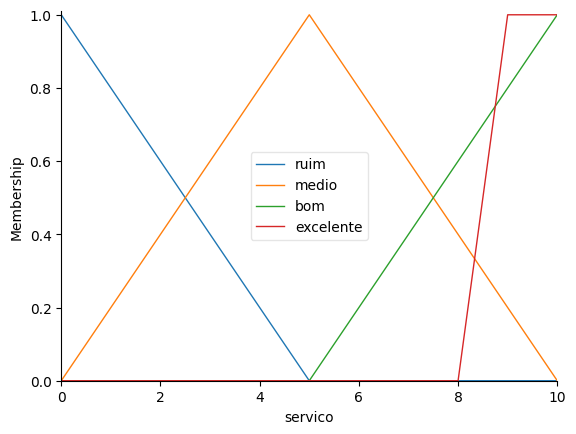

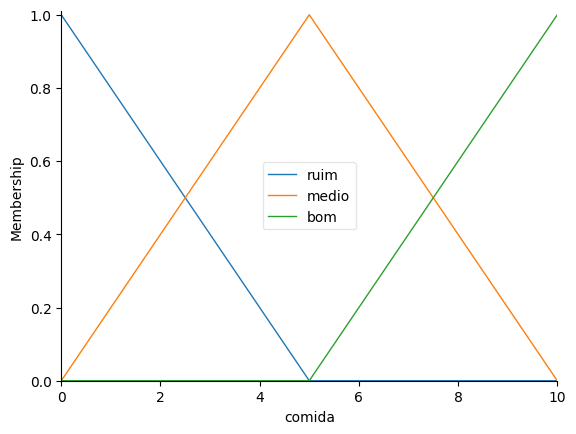

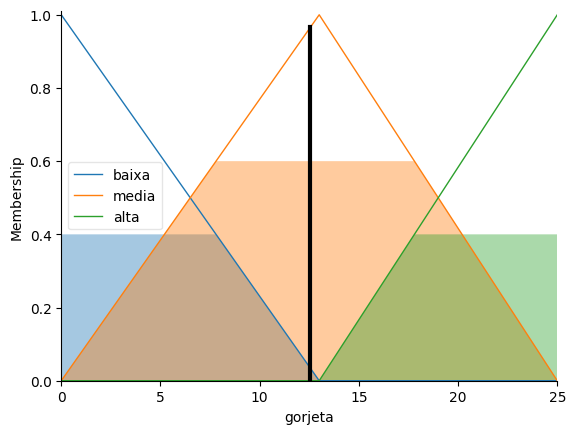

In [7]:
# ============================================================
# AULA DE LÓGICA FUZZY - Código 2
# EXPERIMENTO 4 - CONJUNTO "EXCELENTE"
# Google Colab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================================
# 1) VARIÁVEIS LINGUÍSTICAS
# ============================================================

servico = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "servico"
)

comida = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "comida"
)

gorjeta = ctrl.Consequent(
    np.arange(0, 25.01, 0.5),
    "gorjeta"
)

# ============================================================
# 2) CONJUNTOS FUZZY DO SERVIÇO E DA COMIDA
# ============================================================

# Serviço

servico["ruim"] = fuzz.trimf(
    servico.universe,
    [0, 0, 5]
)

servico["medio"] = fuzz.trimf(
    servico.universe,
    [0, 5, 10]
)

servico["bom"] = fuzz.trimf(
    servico.universe,
    [5, 10, 10]
)

# NOVO CONJUNTO: EXCELENTE

servico["excelente"] = fuzz.trapmf(
    servico.universe,
    [8, 9, 10, 10]
)

# Comida

comida["ruim"] = fuzz.trimf(
    comida.universe,
    [0, 0, 5]
)

comida["medio"] = fuzz.trimf(
    comida.universe,
    [0, 5, 10]
)

comida["bom"] = fuzz.trimf(
    comida.universe,
    [5, 10, 10]
)

# ============================================================
# 3) CONJUNTOS FUZZY DA GORJETA
# ============================================================

gorjeta["baixa"] = fuzz.trimf(
    gorjeta.universe,
    [0, 0, 13]
)

gorjeta["media"] = fuzz.trimf(
    gorjeta.universe,
    [0, 13, 25]
)

gorjeta["alta"] = fuzz.trimf(
    gorjeta.universe,
    [13, 25, 25]
)

# ============================================================
# 4) BASE DE REGRAS
# ============================================================

regras = [

    # Serviço ruim OU comida ruim -> gorjeta baixa
    ctrl.Rule(
        servico["ruim"] | comida["ruim"],
        gorjeta["baixa"]
    ),

    # Serviço médio E comida média -> gorjeta média
    ctrl.Rule(
        servico["medio"] & comida["medio"],
        gorjeta["media"]
    ),

    # Serviço bom OU comida boa -> gorjeta alta
    ctrl.Rule(
        servico["bom"] | comida["bom"],
        gorjeta["alta"]
    ),

    # NOVA REGRA:
    # Serviço excelente -> gorjeta alta
    ctrl.Rule(
        servico["excelente"],
        gorjeta["alta"]
    )
]

# ============================================================
# 5) CRIAR O SISTEMA FUZZY
# ============================================================

sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

# ============================================================
# 6) ENTRADA DAS NOTAS
# ============================================================

def pedir_nota(texto, padrao):

    resposta = input(
        f"{texto} (0-10) [{padrao}]: "
    ).strip()

    if resposta == "":
        return padrao

    return float(
        resposta.replace(",", ".")
    )


nota_servico = pedir_nota(
    "Nota do serviço",
    7
)

nota_comida = pedir_nota(
    "Nota da comida",
    3
)

# ============================================================
# 7) EXECUTAR A SIMULAÇÃO
# ============================================================

sim.input["servico"] = nota_servico
sim.input["comida"] = nota_comida

sim.compute()

# ============================================================
# 8) MOSTRAR RESULTADO
# ============================================================

resultado = sim.output["gorjeta"]

print()
print("=" * 55)
print("EXPERIMENTO 4 - CONJUNTO EXCELENTE")
print("=" * 55)

print(f"Nota do serviço: {nota_servico}")
print(f"Nota da comida:  {nota_comida}")
print(f"Gorjeta sugerida: {resultado:.2f}%")

print("=" * 55)

# ============================================================
# 9) MOSTRAR GRÁFICOS
# ============================================================

servico.view()
plt.show()

comida.view()
plt.show()

gorjeta.view(sim=sim)
plt.show()


In [8]:
# ============================================================
# AULA DE LÓGICA FUZZY - Código 2
# EXPERIMENTO 5 - TESTES DE ENTRADA
# Google Colab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================================
# 1) VARIÁVEIS LINGUÍSTICAS
# ============================================================

servico = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "servico"
)

comida = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "comida"
)

gorjeta = ctrl.Consequent(
    np.arange(0, 25.01, 0.5),
    "gorjeta"
)

# ============================================================
# 2) CONJUNTOS FUZZY
# ============================================================

# Serviço

servico["ruim"] = fuzz.trimf(
    servico.universe,
    [0, 0, 5]
)

servico["medio"] = fuzz.trimf(
    servico.universe,
    [0, 5, 10]
)

servico["bom"] = fuzz.trimf(
    servico.universe,
    [5, 10, 10]
)

servico["excelente"] = fuzz.trapmf(
    servico.universe,
    [8, 9, 10, 10]
)

# Comida

comida["ruim"] = fuzz.trimf(
    comida.universe,
    [0, 0, 5]
)

comida["medio"] = fuzz.trimf(
    comida.universe,
    [0, 5, 10]
)

comida["bom"] = fuzz.trimf(
    comida.universe,
    [5, 10, 10]
)

# ============================================================
# 3) CONJUNTOS FUZZY DA GORJETA
# ============================================================

gorjeta["baixa"] = fuzz.trimf(
    gorjeta.universe,
    [0, 0, 13]
)

gorjeta["media"] = fuzz.trimf(
    gorjeta.universe,
    [0, 13, 25]
)

gorjeta["alta"] = fuzz.trimf(
    gorjeta.universe,
    [13, 25, 25]
)

# ============================================================
# 4) REGRAS
# ============================================================

regras = [

    ctrl.Rule(
        servico["ruim"] | comida["ruim"],
        gorjeta["baixa"]
    ),

    ctrl.Rule(
        servico["medio"] & comida["medio"],
        gorjeta["media"]
    ),

    ctrl.Rule(
        servico["bom"] | comida["bom"],
        gorjeta["alta"]
    ),

    ctrl.Rule(
        servico["excelente"],
        gorjeta["alta"]
    )
]

# ============================================================
# 5) CRIAR SISTEMA
# ============================================================

sistema = ctrl.ControlSystem(regras)

# ============================================================
# 6) TESTES
# ============================================================

testes = [
    (0, 0),
    (10, 10),
    (5, 5)
]

print()
print("=" * 60)
print("EXPERIMENTO 5 - TESTES DE ENTRADA")
print("=" * 60)

for nota_servico, nota_comida in testes:

    sim = ctrl.ControlSystemSimulation(sistema)

    sim.input["servico"] = nota_servico
    sim.input["comida"] = nota_comida

    sim.compute()

    resultado = sim.output["gorjeta"]

    print(
        f"Serviço = {nota_servico:>4.1f} | "
        f"Comida = {nota_comida:>4.1f} | "
        f"Gorjeta = {resultado:>6.2f}%"
    )

print("=" * 60)



EXPERIMENTO 5 - TESTES DE ENTRADA
Serviço =  0.0 | Comida =  0.0 | Gorjeta =   4.33%
Serviço = 10.0 | Comida = 10.0 | Gorjeta =  21.00%
Serviço =  5.0 | Comida =  5.0 | Gorjeta =  12.67%


In [9]:
!pip install --upgrade scikit-fuzzy networkx


Nota do serviço (0-10) [7]: 7
Nota da comida (0-10) [3]: 3

Nota do serviço: 7.0
Nota da comida:  3.0
Gorjeta sugerida: 12.5%


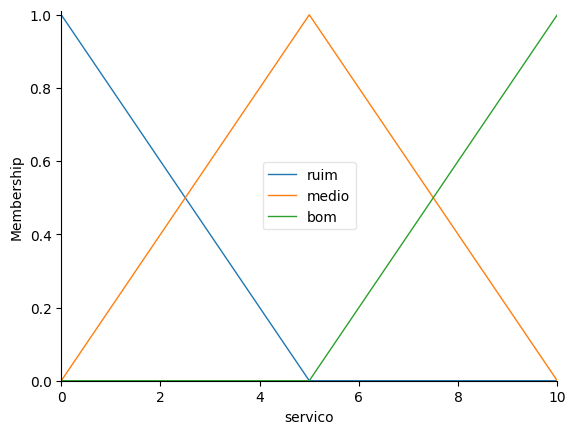

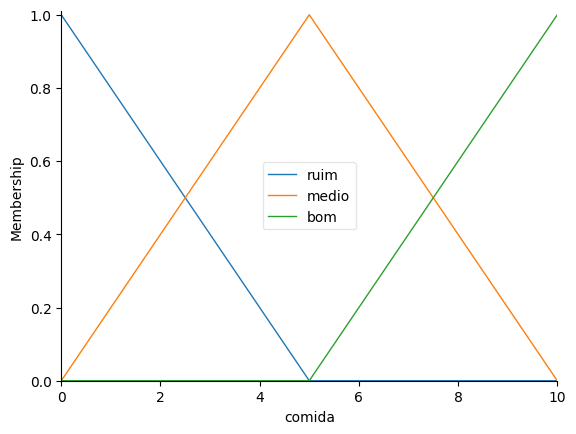

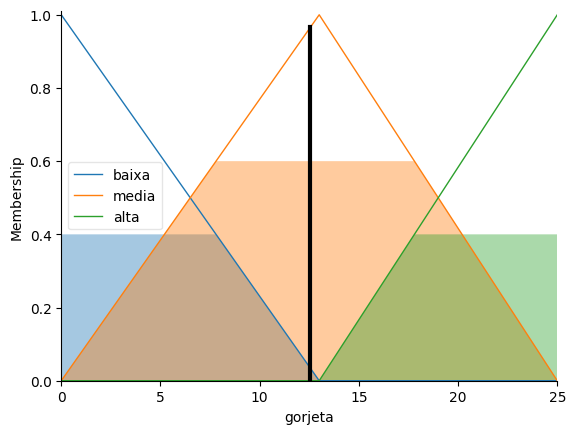

In [1]:
# ============================================================
# AULA DE LÓGICA FUZZY - Código 2
# Laboratório dos alunos - Google Colab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================================
# 1) VARIÁVEIS LINGUÍSTICAS
# ============================================================

servico = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "servico"
)

comida = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "comida"
)

gorjeta = ctrl.Consequent(
    np.arange(0, 25.01, 0.5),
    "gorjeta"
)

# ============================================================
# 2) CONJUNTOS FUZZY
# ============================================================

for var in (servico, comida):

    var["ruim"] = fuzz.trimf(
        var.universe,
        [0, 0, 5]
    )

    var["medio"] = fuzz.trimf(
        var.universe,
        [0, 5, 10]
    )

    var["bom"] = fuzz.trimf(
        var.universe,
        [5, 10, 10]
    )

# Conjuntos fuzzy da gorjeta

gorjeta["baixa"] = fuzz.trimf(
    gorjeta.universe,
    [0, 0, 13]
)

gorjeta["media"] = fuzz.trimf(
    gorjeta.universe,
    [0, 13, 25]
)

gorjeta["alta"] = fuzz.trimf(
    gorjeta.universe,
    [13, 25, 25]
)

# ============================================================
# 3) BASE DE REGRAS
# ============================================================

regras = [

    # Se serviço é ruim OU comida é ruim,
    # então a gorjeta é baixa.
    ctrl.Rule(
        servico["ruim"] | comida["ruim"],
        gorjeta["baixa"]
    ),

    # Se serviço é médio,
    # então a gorjeta é média.
    ctrl.Rule(
        servico["medio"],
        gorjeta["media"]
    ),

    # Se serviço é bom OU comida é boa,
    # então a gorjeta é alta.
    ctrl.Rule(
        servico["bom"] | comida["bom"],
        gorjeta["alta"]
    )
]

# ============================================================
# 4) CRIAR O SISTEMA FUZZY
# ============================================================

sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

# ============================================================
# 5) ENTRADA DAS NOTAS
# ============================================================

def pedir_nota(texto, padrao):

    resposta = input(
        f"{texto} (0-10) [{padrao}]: "
    ).strip()

    if resposta == "":
        return padrao

    return float(
        resposta.replace(",", ".")
    )


# Nota do serviço
nota_servico = pedir_nota(
    "Nota do serviço",
    7
)

# Nota da comida
nota_comida = pedir_nota(
    "Nota da comida",
    3
)

# ============================================================
# 6) EXECUTAR A SIMULAÇÃO
# ============================================================

sim.input["servico"] = nota_servico
sim.input["comida"] = nota_comida

sim.compute()

# ============================================================
# 7) MOSTRAR O RESULTADO
# ============================================================

resultado = sim.output["gorjeta"]

print()
print("=" * 50)
print(f"Nota do serviço: {nota_servico}")
print(f"Nota da comida:  {nota_comida}")
print(f"Gorjeta sugerida: {resultado:.1f}%")
print("=" * 50)

# ============================================================
# 8) MOSTRAR OS GRÁFICOS
# ============================================================

servico.view()
plt.show()

comida.view()
plt.show()

gorjeta.view(sim=sim)
plt.show()
